In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, average_precision_score,precision_recall_curve
import joblib

In [3]:
df = pd.read_csv("../data/creditcard.csv")
df["LogAmount"] = np.log1p(df["Amount"])

X = df.drop(["Class", "Amount"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

In [4]:
#model.fit(X_train, y_train)

In [5]:
model = joblib.load("../models/random_forest.pkl")

In [6]:
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:,1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auprc = average_precision_score(y_test, y_scores)

print("Precision:", precision)
print("Recall:", recall)
print("AUPRC:", auprc)

Precision: 0.961038961038961
Recall: 0.7551020408163265
AUPRC: 0.8589296561447801


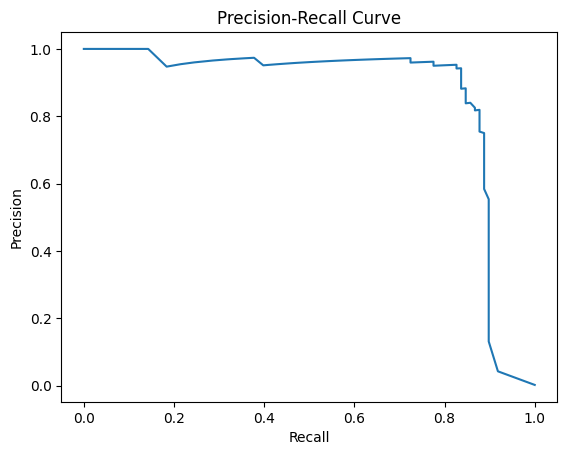

In [7]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

print("AUPRC per fold:", scores)
print("Mean AUPRC:", scores.mean())

AUPRC per fold: [0.83035605 0.89686863 0.85978383 0.85138835 0.82219372]
Mean AUPRC: 0.8521181160162984
